In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pyplot


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1QLmFFs5GYZlrfZPZp6FKtP3UnSidDwwh")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df[df['Exam_Score'] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [ ]:
df = df.drop(df[df['Exam_Score'] > 100].index)

In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


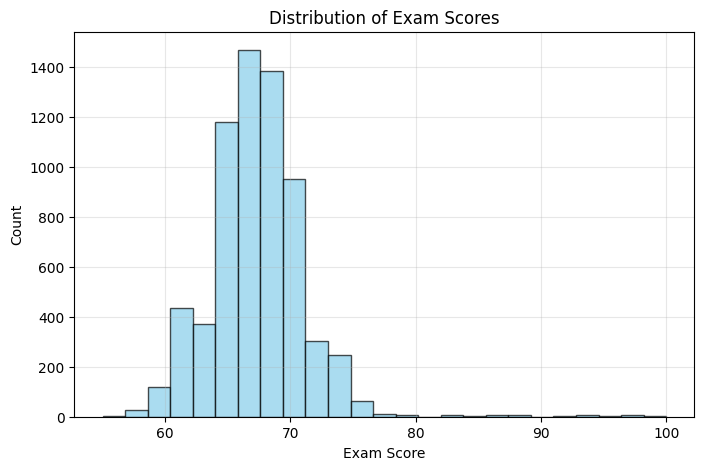

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
plt.hist(df['Exam_Score'], bins=25, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

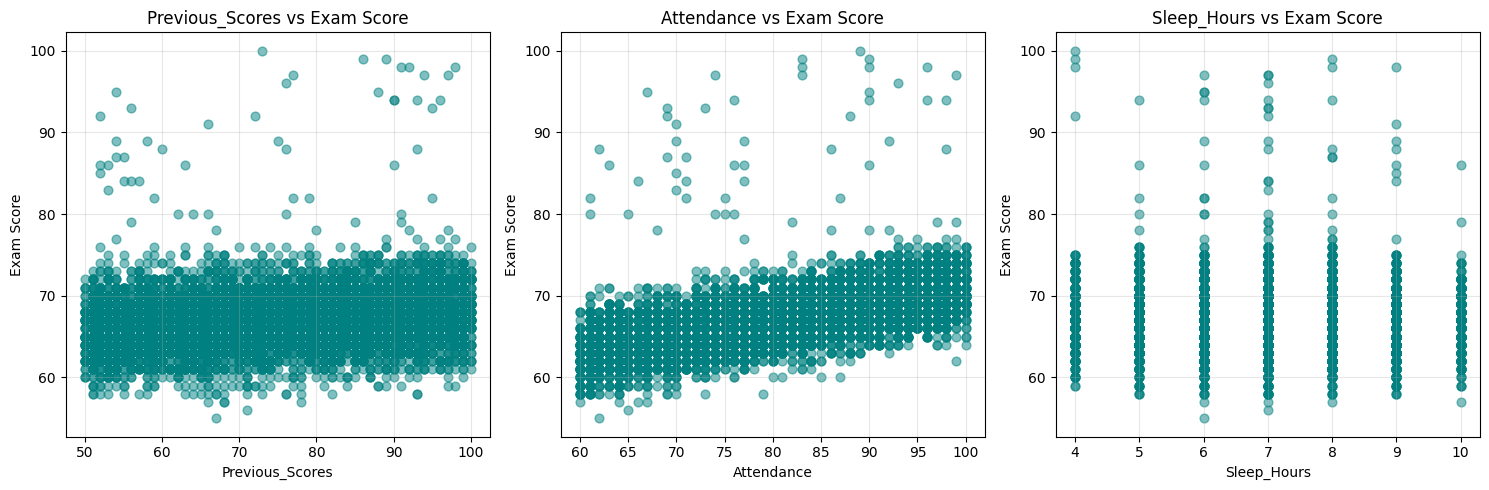

In [ ]:
key_numerics = ['Previous_Scores', 'Attendance', 'Sleep_Hours']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(key_numerics):
    axes[i].scatter(df[col], df['Exam_Score'], alpha=0.5, color='teal', s=40)
    axes[i].set_title(f'{col} vs Exam Score')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Exam Score')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

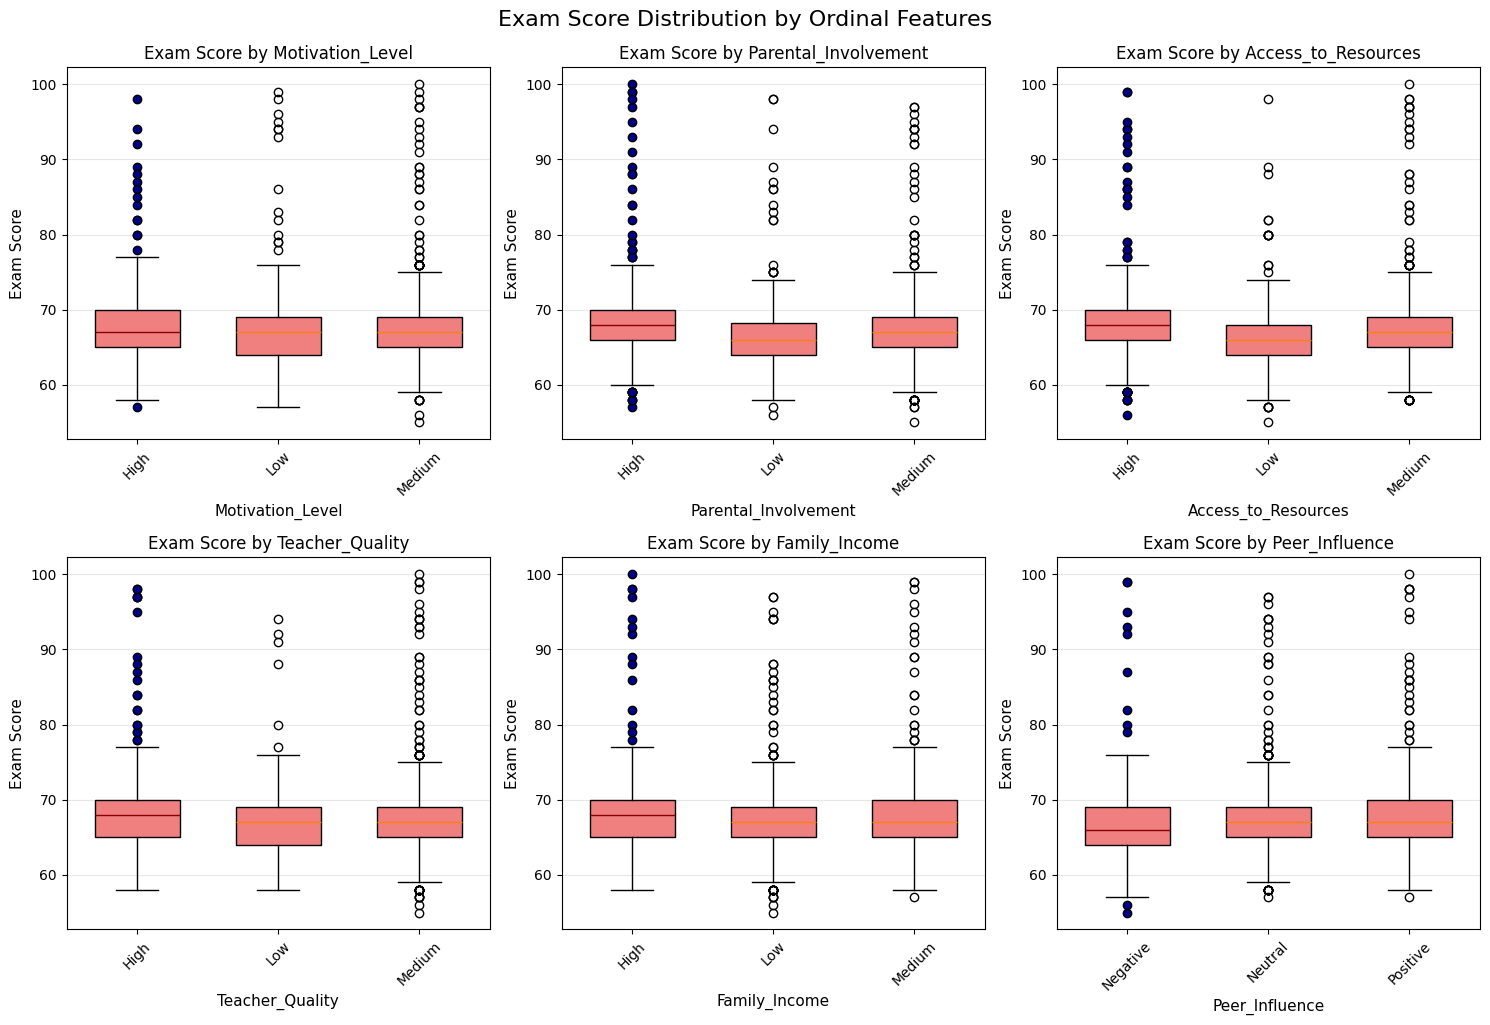

In [ ]:
import matplotlib.pyplot as plt

# List the ordinal/categorical columns for comparison
ordinal_features = [
    'Motivation_Level',
    'Parental_Involvement',
    'Access_to_Resources',
    'Teacher_Quality',
    'Family_Income',
    'Peer_Influence'
]

# Create a grid of subplots (2 rows × 3 columns = 6 plots)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()  # flatten so we can use axes[0], axes[1], etc.

# Loop through each feature
for i, col in enumerate(ordinal_features):

    if col not in df.columns:
        print(f"Column '{col}' not found in dataset — skipping")
        continue

    # Group the Exam_Score values by each category
    grouped = df.groupby(col)['Exam_Score'].apply(list)

    # Get the category names (labels) and the lists of scores
    labels = grouped.index
    score_lists = grouped.values

    # Create the boxplot
    bp = axes[i].boxplot(score_lists,
                         patch_artist=True,              # fill boxes with color
                         tick_labels=labels,
                         widths=0.6)

    # Customize colors
    for box in bp['boxes']:
        box.set_facecolor('lightcoral')
        box.set_edgecolor('black')

    bp['medians'][0].set_color('darkred')     # median line color
    bp['whiskers'][0].set_color('black')      # whiskers
    bp['whiskers'][1].set_color('black')
    bp['caps'][0].set_color('black')
    bp['caps'][1].set_color('black')
    bp['fliers'][0].set_markerfacecolor('darkblue')  # outliers
    bp['fliers'][0].set_markeredgecolor('black')

    # Titles and labels
    axes[i].set_title(f'Exam Score by {col}', fontsize=12)
    axes[i].set_ylabel('Exam Score', fontsize=11)
    axes[i].set_xlabel(col, fontsize=11)

    # Rotate long category names if needed
    axes[i].tick_params(axis='x', rotation=45)

    # Light grid only on y-axis
    axes[i].grid(True, axis='y', alpha=0.3)

# Remove empty subplots if we have fewer features than grid slots
for j in range(len(ordinal_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()   # prevent overlapping labels
plt.suptitle('Exam Score Distribution by Ordinal Features', fontsize=16, y=1.02)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6606 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6606 non-null   int64 
 1   Attendance                  6606 non-null   int64 
 2   Parental_Involvement        6606 non-null   object
 3   Access_to_Resources         6606 non-null   object
 4   Extracurricular_Activities  6606 non-null   object
 5   Sleep_Hours                 6606 non-null   int64 
 6   Previous_Scores             6606 non-null   int64 
 7   Motivation_Level            6606 non-null   object
 8   Internet_Access             6606 non-null   object
 9   Tutoring_Sessions           6606 non-null   int64 
 10  Family_Income               6606 non-null   object
 11  Teacher_Quality             6528 non-null   object
 12  School_Type                 6606 non-null   object
 13  Peer_Influence              6606 non-null   object
 1

In [ ]:
data = df.copy()

In [ ]:
# Fill in missing values (categorical with mode)
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
  data[col] = data[col].fillna(data[col].mode()[0])

In [ ]:
data.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
unique_values  = {col: data[col].unique()
                        for col in data.select_dtypes(include= 'object') }
unique_values

{'Parental_Involvement': array(['Low', 'Medium', 'High'], dtype=object),
 'Access_to_Resources': array(['High', 'Medium', 'Low'], dtype=object),
 'Extracurricular_Activities': array(['No', 'Yes'], dtype=object),
 'Motivation_Level': array(['Low', 'Medium', 'High'], dtype=object),
 'Internet_Access': array(['Yes', 'No'], dtype=object),
 'Family_Income': array(['Low', 'Medium', 'High'], dtype=object),
 'Teacher_Quality': array(['Medium', 'High', 'Low'], dtype=object),
 'School_Type': array(['Public', 'Private'], dtype=object),
 'Peer_Influence': array(['Positive', 'Negative', 'Neutral'], dtype=object),
 'Learning_Disabilities': array(['No', 'Yes'], dtype=object),
 'Parental_Education_Level': array(['High School', 'College', 'Postgraduate'], dtype=object),
 'Distance_from_Home': array(['Near', 'Moderate', 'Far'], dtype=object),
 'Gender': array(['Male', 'Female'], dtype=object)}

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# For binary like data
binary_cols = ['Internet_Access', 'Extracurricular_Activities', 'School_Type', 'Learning_Disabilities', 'Gender']
for col in binary_cols:
  data[col] = LabelEncoder().fit_transform(data[col])

# Ordinal (Low/Med/High) can map manually for better meaning
ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}
ordinal_cols = ['Parental_Involvement', 'Teacher_Quality', 'Motivation_Level', 'Family_Income', 'Access_to_Resources']
for cols in ordinal_cols:
  data[cols] = data[cols].map(ordinal_map)

# One-hot encode nominal categories
onehot = OneHotEncoder()
nominal_cols = ['Peer_Influence', 'Distance_from_Home', 'Parental_Education_Level']
data = pd.get_dummies(data, columns= nominal_cols, dtype= int)

In [ ]:
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Exam_Score,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive,Distance_from_Home_Far,Distance_from_Home_Moderate,Distance_from_Home_Near,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate
0,23,84,0,2,0,7,73,0,1,0,...,67,0,0,1,0,0,1,0,1,0
1,19,64,0,1,0,8,59,0,1,2,...,61,1,0,0,0,1,0,1,0,0
2,24,98,1,1,1,7,91,1,1,2,...,74,0,1,0,0,0,1,0,0,1
3,29,89,0,1,1,8,98,1,1,1,...,71,1,0,0,0,1,0,0,1,0
4,19,92,1,1,1,6,65,1,1,3,...,70,0,1,0,0,0,1,1,0,0


In [ ]:
data = data.drop(axis=1, columns='Previous_Scores')

In [ ]:
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,...,Exam_Score,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive,Distance_from_Home_Far,Distance_from_Home_Moderate,Distance_from_Home_Near,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate
0,23,84,0,2,0,7,0,1,0,0,...,67,0,0,1,0,0,1,0,1,0
1,19,64,0,1,0,8,0,1,2,1,...,61,1,0,0,0,1,0,1,0,0
2,24,98,1,1,1,7,1,1,2,1,...,74,0,1,0,0,0,1,0,0,1
3,29,89,0,1,1,8,1,1,1,1,...,71,1,0,0,0,1,0,0,1,0
4,19,92,1,1,1,6,1,1,3,1,...,70,0,1,0,0,0,1,1,0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import Ridge

# stating feature and target variable(s)
x = data.drop(axis=1, columns='Exam_Score')
y = data['Exam_Score']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = Ridge(alpha= 0.5)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

#model.score(x_test, y_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Absolute Error: 0.77
Mean Squared Error: 2.77
Root Mean Squared Error: 1.67
R-squared: 0.79


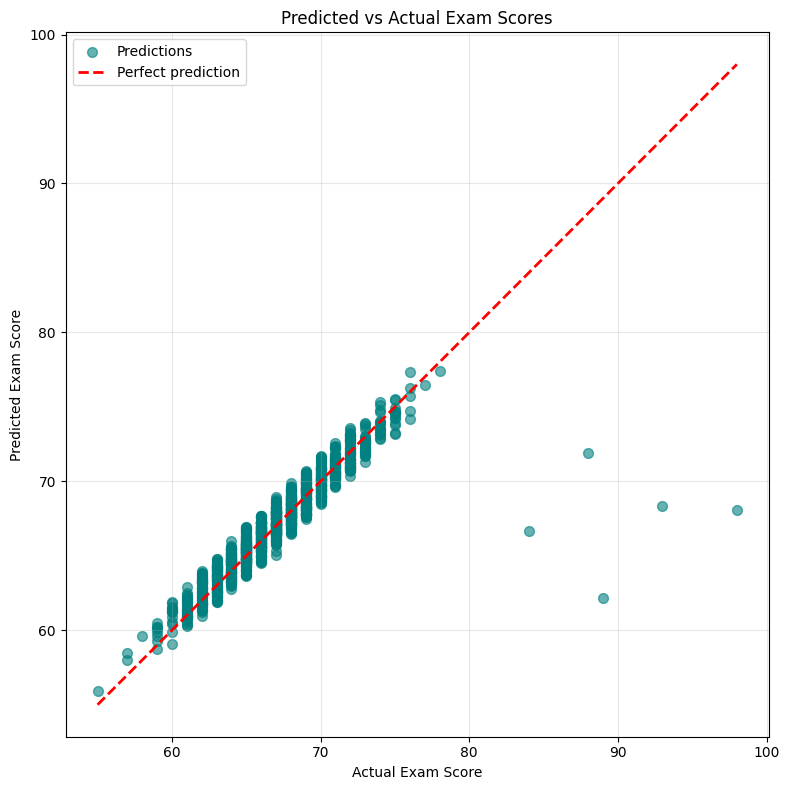

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))

# Scatter of predictions vs truth
plt.scatter(y_test, y_pred, alpha=0.6, color='teal', s=50, label='Predictions')

# Perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Predicted vs Actual Exam Scores')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()